# 🚗 Car Price Prediction using Linear Regression

This notebook teaches **Linear Regression** using a Kaggle used-car dataset with theory, implementation, and explanations.

## Theory: Linear Regression
Linear Regression predicts a continuous value using a linear relationship between features and target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**Explanation:** Load the dataset and view first few rows.

In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


**Explanation:** Understand dataset size and data types.

In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

**Explanation:** Check for missing values.

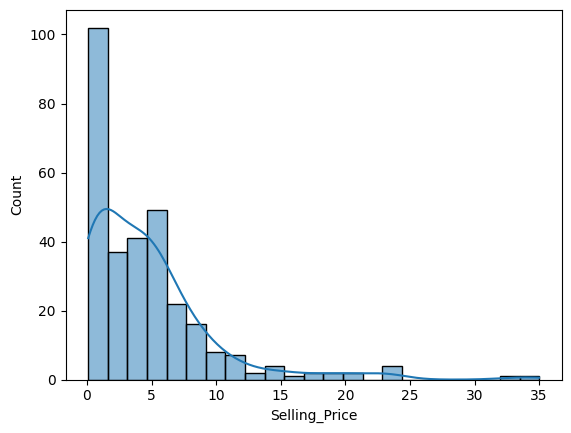

In [5]:
sns.histplot(df['Selling_Price'], kde=True)
plt.show()

**Explanation:** Visualize price distribution.

In [6]:
df=pd.get_dummies(df,drop_first=True)
df

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,4.75,9.54,43000,0,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,7.25,9.85,6900,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,2.85,4.15,5200,0,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,4.60,6.87,42450,0,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
297,2015,4.00,5.90,60000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
298,2009,3.35,11.00,87934,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
299,2017,11.50,12.50,9000,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


**Explanation:** Encode categorical variables.

In [7]:
X = df.drop(['Selling_Price'],axis=1)
Y= df["Selling_Price"]

In [8]:
X

,Year,Present_Price,Driven_kms,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,Car_Name_Bajaj Avenger 220,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,5.59,27000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,9.54,43000,0,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,9.85,6900,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,4.15,5200,0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,6.87,42450,0,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,2016,11.60,33988,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
297,2015,5.90,60000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
298,2009,11.00,87934,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
299,2017,12.50,9000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [9]:
Y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

**Explanation:** Separate features and target.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size= 0.2, random_state= 42) 

**Explanation:** Split data into training and testing sets.

In [11]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Explanation:** Train Linear Regression model.

In [12]:
X_train

,Year,Present_Price,Driven_kms,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,Car_Name_Bajaj Avenger 220,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
184,2008,0.750,26000,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
132,2017,0.950,3500,0,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,True,True
194,2008,0.787,50000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
75,2015,6.800,36000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
111,2016,1.500,8700,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2013,0.570,18000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
71,2011,12.480,45000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
106,2014,3.450,16500,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
270,2011,10.000,69341,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True


In [13]:
Y_pred = model.predict(X_test)

In [14]:
Y_pred

array([ 7.47327051,  9.58880632,  5.56883578, -0.40941815,  8.55896043,
        6.88890857,  1.47635719,  6.23695329,  0.98014478,  6.68925428,
       15.63172868,  0.29557627,  7.97759508,  8.08373759,  6.19289061,
        2.70151483,  2.72386344, 10.98923224,  7.77090451,  8.56271721,
        5.55477855,  7.63455899,  5.6498586 ,  1.89746929,  6.25342368,
        3.48912822,  5.48662283,  1.6085983 ,  2.6805568 ,  2.67421952,
       -0.03307212,  9.11656913, -2.33116821,  1.98326133,  8.36119393,
        3.98900218,  6.09888859,  6.17398282,  4.27677317,  6.74710603,
        5.51688689,  8.34755944,  3.67455712,  0.25706046, 13.06489129,
        0.04497286,  8.34319661,  9.55198302,  3.90152259,  4.03845455,
        5.9287072 ,  2.70075543, 22.92984367, 20.60225579,  7.30522747,
        9.84045173,  4.59171221,  8.91665681,  0.05897455,  6.62617599,
        3.66819743])

**Explanation:** Make predictions on test data.

In [15]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

mae = mean_absolute_error(Y_test,Y_pred)
mse = mean_squared_error(Y_test,Y_pred)
rmse= np.sqrt(mse)
r2 = r2_score(Y_test,Y_pred)
mae,mse,r2

(2.03651747910716, 9.221090393073414, 0.5997023481235617)

**Explanation:** Evaluate model performance.

Text(0, 0.5, 'Predicted Price')

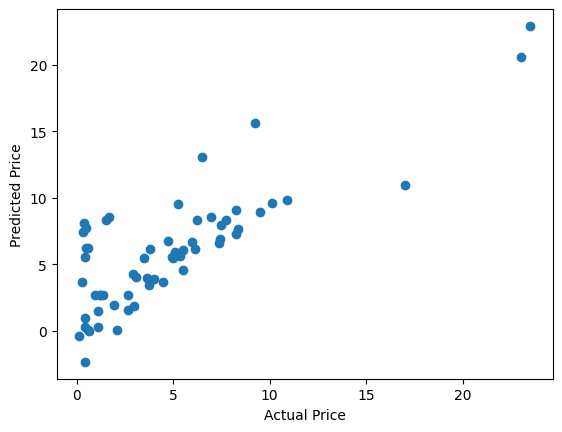

In [16]:
plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")


**Explanation:** Compare actual vs predicted prices visually.